# TDA SPARSE INDEX TRACKING REPLICATION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import requests
import warnings
import cvxpy as cp
import ripser
import gudhi.representations as gr
from tqdm import tqdm
warnings.filterwarnings("ignore")

In [3]:
def get_sp500_tickers():
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    tables = pd.read_html(response.text)
    sp500_table = tables[0]
    tickers = sp500_table["Symbol"].tolist()
    tickers = [t.replace(".", "-") for t in tickers]
    print(f"Found {len(tickers)} tickers")
    return tickers
tickers = get_sp500_tickers()
print(tickers[:10])

Found 503 tickers
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


### Data Downloading

In [5]:
def download_data(tickers, start="1999-10-11", end="2023-03-08", index_ticker="^GSPC", batch_size=50):
    all_prices = {}
    failed = []
    # Download index
    print(f"Downloading Index {index_ticker}...")
    index_data = yf.download(
        index_ticker,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False)
    if index_data.empty:
        raise ValueError("Index data failed to download.")

    all_prices[index_ticker] = index_data["Close"].squeeze()

    # Download stocks in batches
    n_batches = int(np.ceil(len(tickers) / batch_size))

    for i in range(n_batches):
        current_batch = tickers[i * batch_size : (i + 1) * batch_size]

        if len(current_batch) == 0:
            continue

        print(f"Batch {i+1}/{n_batches}: downloading {len(current_batch)} tickers...")

        try:
            data = yf.download(
                current_batch,
                start=start,
                end=end,
                auto_adjust=True,
                progress=False,
                group_by="column"
            )
            if data.empty:
                failed.extend(current_batch)
                continue

            if isinstance(data.columns, pd.MultiIndex):
                if "Close" in data.columns.get_level_values(0):
                    close_data = data["Close"]
                else:
                    failed.extend(current_batch)
                    continue
            else:
                close_data = data[["Close"]]
                close_data.columns = current_batch

            for ticker in current_batch:
                if ticker in close_data.columns:
                    series = close_data[ticker].squeeze()

                    # Treat completely empty series as failed
                    if series.dropna().empty:
                        failed.append(ticker)
                    else:
                        all_prices[ticker] = series
                else:
                    failed.append(ticker)

        except Exception as e:
            print(f"Batch {i+1} failed: {e}")
            failed.extend(current_batch)

    prices_df = pd.DataFrame(all_prices)
    prices_df = prices_df.sort_index()

    print(f"\nFailed to download: {len(set(failed))} tickers")
    print(f"Successfully downloaded: {prices_df.shape[1] - 1} stocks + index")
    print(f"Shape: {prices_df.shape}")
    print(f"Date range: {prices_df.index.min()} to {prices_df.index.max()}")

    return prices_df, sorted(list(set(failed)))
prices_df, failed = download_data(tickers)
print("\nFirst rows:")
display(prices_df.head())

Batch 1/11: downloading 50 tickers...
Batch 2/11: downloading 50 tickers...
Batch 3/11: downloading 50 tickers...
Batch 4/11: downloading 50 tickers...
Batch 5/11: downloading 50 tickers...



1 Failed download:
['GEV']: YFPricesMissingError('possibly delisted; no price data found  (1d 1999-10-11 -> 2023-03-08) (Yahoo error = "Data doesn\'t exist for startDate = 939614400, endDate = 1678251600")')


Batch 6/11: downloading 50 tickers...



1 Failed download:
['KVUE']: YFPricesMissingError('possibly delisted; no price data found  (1d 1999-10-11 -> 2023-03-08) (Yahoo error = "Data doesn\'t exist for startDate = 939614400, endDate = 1678251600")')


Batch 7/11: downloading 50 tickers...
Batch 8/11: downloading 50 tickers...


...


2 Failed downloads:
['SNDK', 'SOLV']: YFPricesMissingError('possibly delisted; no price data found  (1d 1999-10-11 -> 2023-03-08) (Yahoo error = "Data doesn\'t exist for startDate = 939614400, endDate = 1678251600")')


Batch 10/11: downloading 50 tickers...



1 Failed download:
['VLTO']: YFPricesMissingError('possibly delisted; no price data found  (1d 1999-10-11 -> 2023-03-08) (Yahoo error = "Data doesn\'t exist for startDate = 939614400, endDate = 1678251600")')


Batch 11/11: downloading 3 tickers...

Failed to download: 6 tickers
Successfully downloaded: 497 stocks + index
Shape: (5889, 498)
Date range: 1999-10-11 00:00:00 to 2023-03-07 00:00:00

First rows:


,^GSPC,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
1999-10-11,1335.209961,19.277576,3.117105,9.481833,NaN,NaN,14.888315,9.50000,17.712000,6.642322,...,10.380817,NaN,NaN,NaN,7.211613,NaN,5.076915,21.277779,NaN,NaN
1999-10-12,1313.040039,18.744909,3.027126,9.253015,NaN,NaN,14.647934,9.37500,17.239149,6.679327,...,10.730927,NaN,NaN,NaN,7.211613,NaN,5.046739,21.888889,NaN,NaN
1999-10-13,1285.550049,18.427845,2.969285,8.889950,NaN,NaN,14.516110,9.12500,16.864817,6.596066,...,10.345803,NaN,NaN,NaN,7.253788,NaN,4.699728,21.722221,NaN,NaN
1999-10-14,1283.420044,18.643454,2.943576,8.818139,NaN,NaN,14.663444,9.00000,16.707203,6.559060,...,10.275784,NaN,NaN,NaN,7.317043,NaN,4.744991,21.777779,NaN,NaN
1999-10-15,1247.410034,18.136150,2.956430,8.631436,NaN,NaN,14.562636,8.78125,16.155542,6.364789,...,9.645582,NaN,NaN,NaN,7.190525,NaN,4.707272,21.347221,NaN,NaN


### Periods

In [6]:
period1_start = "1999-10-11"
period1_end = "2018-10-10"
period2_start = "2018-01-01"
period2_end = "2023-03-08"
index_col = "^GSPC"
prices_p1_raw = prices_df.loc[period1_start:period1_end].copy()
prices_p2_raw = prices_df.loc[period2_start:period2_end].copy()
print("Raw Period 1 prices shape:", prices_p1_raw.shape)
print("Raw Period 2 prices shape:", prices_p2_raw.shape)

Raw Period 1 prices shape: (4782, 498)
Raw Period 2 prices shape: (1303, 498)


### Data Cleaning

In [7]:
def clean_panel_prices(prices, index_col="^GSPC", min_coverage=0.95):
    prices = prices.copy()
    # Keep only dates where the index has valid price
    prices = prices.dropna(subset=[index_col])
    # Separate index and stocks
    index_prices = prices[[index_col]]
    stock_prices = prices.drop(columns=[index_col])
    # Coverage for each stock
    coverage = stock_prices.notna().mean()
    # Stocks with enough data
    keep_stocks = coverage[coverage >= min_coverage].index.tolist()
    # Combine index and selected stocks
    cleaned = pd.concat([index_prices, stock_prices[keep_stocks]], axis=1)
    # Final alignment: remove remaining rows with any missing values
    cleaned = cleaned.dropna(axis=0)

    return cleaned, coverage


prices_p1, coverage_p1 = clean_panel_prices(prices_p1_raw, index_col=index_col, min_coverage=0.95)
prices_p2, coverage_p2 = clean_panel_prices(prices_p2_raw, index_col=index_col,min_coverage=0.95)

print("\nAfter cleaning:")
print("Panel 1:")
print(prices_p1.index.min(), "to", prices_p1.index.max())
print("Trading days:", prices_p1.shape[0])
print("Stocks:", prices_p1.shape[1] - 1)

print("\nPanel 2:")
print(prices_p2.index.min(), "to", prices_p2.index.max())
print("Trading days:", prices_p2.shape[0])
print("Stocks:", prices_p2.shape[1] - 1)


After cleaning:
Panel 1:
2000-08-11 00:00:00 to 2018-10-10 00:00:00
Trading days: 4570
Stocks: 355

Panel 2:
2018-01-02 00:00:00 to 2023-03-07 00:00:00
Trading days: 1303
Stocks: 477


### Returns

In [9]:
returns_p1 = prices_p1.pct_change().dropna()
returns_p2 = prices_p2.pct_change().dropna()

stock_returns_p1 = returns_p1.drop(columns=[index_col])
index_returns_p1 = returns_p1[index_col]

stock_returns_p2 = returns_p2.drop(columns=[index_col])
index_returns_p2 = returns_p2[index_col]

print("\nReturns:")
print("Panel 1 stocks:", stock_returns_p1.shape)
print("Panel 1 index:", index_returns_p1.shape)
print("Panel 2 stocks:", stock_returns_p2.shape)
print("Panel 2 index:", index_returns_p2.shape)


Returns:
Panel 1 stocks: (4569, 355)
Panel 1 index: (4569,)
Panel 2 stocks: (1302, 477)
Panel 2 index: (1302,)


### Rolling Windows

In [10]:
def create_windows(stock_returns, index_returns, insample=504, oos=21, step=21):
    windows = []
    n_obs = len(stock_returns)

    for start in range(0, n_obs - insample - oos + 1, step):
        end_in = start + insample
        end_oos = end_in + oos

        window = {
            "R_in": stock_returns.iloc[start:end_in],
            "R0_in": index_returns.iloc[start:end_in],

            "R_oos": stock_returns.iloc[end_in:end_oos],
            "R0_oos": index_returns.iloc[end_in:end_oos],

            "train_start": stock_returns.index[start],
            "train_end": stock_returns.index[end_in - 1],

            "oos_start": stock_returns.index[end_in],
            "oos_end": stock_returns.index[end_oos - 1]
        }

        windows.append(window)

    print("Number of windows:", len(windows))

    return windows

windows_p1 = create_windows(stock_returns_p1, index_returns_p1)
windows_p2 = create_windows(stock_returns_p2, index_returns_p2)

Number of windows: 193
Number of windows: 38


### TAKENS EMBEDDING

In [11]:
def takens_embed(return_series, d=3, tau=1):
    x = np.asarray(return_series, dtype=float)
    T = len(x)
    n_points = T - (d - 1) * tau
    if n_points <= 0:
        raise ValueError("Series too short for Takens embedding.")

    X = np.column_stack([
        x[k * tau : k * tau + n_points]
        for k in range(d)
    ])

    return X
def get_subseries(return_series, T_tilde=42, h=21):

    x = np.asarray(return_series, dtype=float)
    T = len(x)

    if T < T_tilde:
        return []

    n_sub = (T - T_tilde) // h + 1

    subseries = [
        x[j * h : j * h + T_tilde]
        for j in range(n_sub)
    ]

    return subseries


# Sanity check
dummy = np.random.randn(504)
subs = get_subseries(dummy, T_tilde=42, h=21)
print(f"\n504-day window gives {len(subs)} sub-series of length {len(subs[0])}")


504-day window gives 23 sub-series of length 42


### PERSISTENT HOMOLOGY

In [22]:
def compute_persistence_diagrams(point_cloud, max_dim=1):
    result = ripser.ripser(point_cloud, maxdim=max_dim)

    dgm0 = result["dgms"][0]
    dgm1 = result["dgms"][1]

    # Remove infinite death values
    dgm0 = dgm0[np.isfinite(dgm0[:, 1])]
    dgm1 = dgm1[np.isfinite(dgm1[:, 1])]

    # Keep only valid birth-death pairs
    dgm0 = dgm0[dgm0[:, 1] > dgm0[:, 0]]
    dgm1 = dgm1[dgm1[:, 1] > dgm1[:, 0]]

    return dgm0, dgm1


def safe_diagram(dgm):
    dgm = np.asarray(dgm, dtype=np.float64)

    if dgm.ndim != 2 or dgm.shape[1] != 2 or len(dgm) == 0:
        return np.array([[0.0, 0.0]], dtype=np.float64)

    return dgm

### TDA LANDSCAPE NORMS

In [23]:
def compute_tda_norms_for_stock(stock_returns, T_tilde=42, h=21, d=3, tau=1, num_landscapes=1,
    resolution=100
):
    stock_returns = np.asarray(stock_returns, dtype=float)
    stock_returns = stock_returns[np.isfinite(stock_returns)]

    subseries_list = get_subseries(
        stock_returns,
        T_tilde=T_tilde,
        h=h)

    if len(subseries_list) == 0:
        return 0.0, 0.0

    all_dgm0 = []
    all_dgm1 = []

    for sub in subseries_list:
        cloud = takens_embed(sub, d=d, tau=tau)

        dgm0, dgm1 = compute_persistence_diagrams(
            cloud,
            max_dim=1)

        all_dgm0.append(safe_diagram(dgm0))
        all_dgm1.append(safe_diagram(dgm1))

    # GUDHI Landscape
    landscaper_h0 = gr.Landscape(
        num_landscapes=num_landscapes,
        resolution=resolution)

    landscaper_h1 = gr.Landscape(
        num_landscapes=num_landscapes,
        resolution=resolution)

    land_h0 = landscaper_h0.fit_transform(all_dgm0)
    land_h1 = landscaper_h1.fit_transform(all_dgm1)

    # Mean landscape across overlapping sub-series
    mean_land_h0 = land_h0.mean(axis=0)
    mean_land_h1 = land_h1.mean(axis=0)

    # Correct L1 numerical integration
    dx = 1.0 / resolution

    alpha_i = np.trapz(np.abs(mean_land_h0), dx=dx)
    beta_i = np.trapz(np.abs(mean_land_h1), dx=dx)

    return float(alpha_i), float(beta_i)

### TDA NORMS FOR ONE WINDOW

In [24]:
def compute_tda_norms_for_window(
    R_in,
    num_landscapes=1,
    resolution=100
):
    alphas = []
    betas = []

    for stock in tqdm(R_in.columns, desc="Computing TDA norms"):
        r_i = R_in[stock].values

        alpha_i, beta_i = compute_tda_norms_for_stock(
            r_i,
            T_tilde=42,
            h=21,
            d=3,
            tau=1,
            num_landscapes=num_landscapes,
            resolution=resolution
        )

        alphas.append(alpha_i)
        betas.append(beta_i)

    alpha = np.asarray(alphas, dtype=float)
    beta = np.asarray(betas, dtype=float)

    return alpha, beta

### OPTIMISATION MODEL

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import math
from tqdm import tqdm

In [26]:
def solve_cvx_problem(problem, verbose=False):
    solver_attempts = [
        ("CLARABEL", cp.CLARABEL),
        ("OSQP", cp.OSQP),
        ("MOSEK", cp.MOSEK),
        ("SCS", cp.SCS)]
    last_error = None

    for solver_name, solver in solver_attempts:
        try:
            problem.solve(solver=solver, verbose=verbose)

            if problem.status in ["optimal", "optimal_inaccurate"]:
                return solver_name

        except Exception as e:
            last_error = e
            continue

    raise ValueError(
        f"All solvers failed. Last error: {last_error}. "
        f"Problem status: {problem.status}")

### TDA OPTIMISATION

In [27]:
def optimise_tda_portfolio(R_in, R0_in, alpha_tda, beta_tda, model="TDA-EN11"):
    R = R_in.values
    R0 = R0_in.values
    T, n = R.shape
    alpha_tda = np.asarray(alpha_tda, dtype=float)
    beta_tda = np.asarray(beta_tda, dtype=float)

    if model == "TE":
        alpha_use = np.zeros(n)
        beta_use = np.zeros(n)

    elif model == "TDA-Lasso":
        alpha_use = alpha_tda.copy()
        beta_use = np.zeros(n)

    elif model == "EN":
        alpha_use = ones.copy()
        beta_use = ones.copy()

    elif model == "Vol-Lasso":
        alpha_use = alpha_tda.copy()
        beta_use = beta_tda.copy()

    elif model == "TDA-EN11":
        alpha_use = alpha_tda.copy()
        beta_use = alpha_tda.copy()

    elif model == "TDA-EN12":
        # TDA-EN12: alpha in L1, beta in L2
        alpha_use = alpha_tda.copy()
        beta_use = beta_tda.copy()

    elif model == "Vol-EN":
        # Volatility Elastic Net: beta in both L1 and L2
        alpha_use = alpha_tda.copy()
        beta_use = beta_tda.copy()

    else:
        raise ValueError("Unknown TDA model. Choose: TE, TDA-Lasso, TDA-EN11, TDA-EN12")

    # Decision variable
    w = cp.Variable(n)

    # Objective
    tracking_error = cp.sum_squares(R @ w - R0)
    l1_penalty = cp.sum(cp.multiply(alpha_use, cp.abs(w)))
    l2_penalty = cp.sum(cp.multiply(beta_use**2, cp.square(w)))

    objective = cp.Minimize(tracking_error + l1_penalty + l2_penalty)

    # Full investment constraint
    constraints = [cp.sum(w) == 1]

    problem = cp.Problem(objective, constraints)
    solver_used = solve_cvx_problem(problem)

    weights = np.asarray(w.value).flatten()
    weights[np.abs(weights) < 1e-8] = 0.0

    return weights, solver_used

### ECONOMIC BETA/VOL PENALTIES

In [29]:
def compute_beta_vol_penalties(
    R_in,
    R0_in,
    eps=1e-6,
    annualise_vol=False,
    normalize=True
):
    R = R_in.values
    R0 = R0_in.values
    R_centered = R - R.mean(axis=0)
    R0_centered = R0 - R0.mean()
    var_index = np.var(R0, ddof=1)
    if var_index <= 0:
        raise ValueError("Index variance is zero. Cannot compute CAPM beta.")

    cov_with_index = np.sum(
        R_centered * R0_centered.reshape(-1, 1),
        axis=0
    ) / (len(R0) - 1)
    beta_capm = cov_with_index / var_index
    sigma = np.std(R, axis=0, ddof=1)
    if annualise_vol:
        sigma = sigma * np.sqrt(252)
    raw_inverse_beta = 1.0 / (np.abs(beta_capm) + eps)
    # Clean invalid values
    raw_inverse_beta = np.where(
        np.isfinite(raw_inverse_beta),
        raw_inverse_beta,
        np.nan)
    sigma = np.where(
        np.isfinite(sigma),
        sigma,
        np.nan)
    raw_inverse_beta = np.where(
        np.isnan(raw_inverse_beta),
        np.nanmedian(raw_inverse_beta),
        raw_inverse_beta
    )

    sigma = np.where(
        np.isnan(sigma),
        np.nanmedian(sigma),
        sigma
    )

    if normalize:
        alpha_beta = raw_inverse_beta / np.mean(raw_inverse_beta)
        b_vol = sigma / np.mean(sigma)
    else:
        alpha_beta = raw_inverse_beta
        b_vol = sigma

    return alpha_beta, b_vol, beta_capm, sigma, raw_inverse_beta

### ECONOMIC EXTENSION OPTIMISATION

In [33]:
def optimise_economic_portfolio(
    R_in,
    R0_in,
    alpha_beta,
    b_vol,
    model="BetaVol"
):
    R = R_in.values
    R0 = R0_in.values
    T, n = R.shape
    alpha_beta = np.asarray(alpha_beta, dtype=float)
    b_vol = np.asarray(b_vol, dtype=float)
    if model == "Vol-EN11":
        alpha_use = b_vol.copy()
        beta_use = b_vol.copy()

    elif model == "Beta-EN11":
        alpha_use = alpha_beta.copy()
        beta_use = alpha_beta.copy()

    elif model == "BetaVol":
        alpha_use = alpha_beta.copy()
        beta_use = b_vol.copy()

    elif model == "BetaVol-Long":
        alpha_use = alpha_beta.copy()
        beta_use = b_vol.copy()

    else:
        raise ValueError(
            "Unknown economic model. Choose: Vol-EN11, Beta-EN11, BetaVol, BetaVol-Long"
        )
    w = cp.Variable(n)
    tracking_error = cp.sum_squares(R @ w - R0)
    l1_penalty = cp.sum(
        cp.multiply(alpha_use, cp.abs(w))
    )
    l2_penalty = cp.sum(
        cp.multiply(beta_use**2, cp.square(w))
    )
    objective = cp.Minimize(
        tracking_error + l1_penalty + l2_penalty
    )
    constraints = [
        cp.sum(w) == 1
    ]
    if model == "BetaVol-Long":
        constraints.append(w >= 0)
    problem = cp.Problem(objective, constraints)
    solver_used = solve_cvx_problem(problem)
    weights = np.asarray(w.value).flatten()
    weights[np.abs(weights) < 1e-8] = 0.0
    return weights, solver_used

### HISTORICAL VaR FORECAST FROM IN-SAMPLE PORTFOLIO RETURNS

In [34]:
def historical_var_threshold(returns, alpha=0.05):
    returns = np.asarray(returns, dtype=float)
    returns = returns[np.isfinite(returns)]
    if len(returns) == 0:
        return np.nan
    return np.quantile(returns, alpha)

### ROLLING BACKTEST: TDA MODELS

In [35]:
def rolling_backtest_tda(
    windows,
    model="TDA-EN11",
    num_landscapes=1,
    resolution=100,
    var_alpha=0.05,
    max_windows=None
):
    all_oos_returns = []
    all_index_returns = []
    all_var_thresholds = []
    weights_records = []
    selected_assets = []
    gross_exposures = []
    alpha_records = []
    beta_records = []
    solver_records = []

    if max_windows is not None:
        windows = windows[:max_windows]

    for k, window in enumerate(windows):

        print(
            f"\nWindow {k+1}/{len(windows)} | Model: {model} | "
            f"Train: {window['train_start'].date()} to {window['train_end'].date()} | "
            f"OOS: {window['oos_start'].date()} to {window['oos_end'].date()}"
        )

        R_in = window["R_in"]
        R0_in = window["R0_in"]
        R_oos = window["R_oos"]
        R0_oos = window["R0_oos"]

        if model == "TE":
            alpha_tda = np.zeros(R_in.shape[1])
            beta_tda = np.zeros(R_in.shape[1])
        else:
            alpha_tda, beta_tda = compute_tda_norms_for_window(
                R_in,
                num_landscapes=num_landscapes,
                resolution=resolution
            )
        weights, solver_used = optimise_tda_portfolio(
            R_in,
            R0_in,
            alpha_tda,
            beta_tda,
            model=model
        )
        # OOS portfolio returns
        portfolio_oos = R_oos.values @ weights
        # In-sample portfolio returns for VaR forecast
        portfolio_in = R_in.values @ weights
        var_threshold = historical_var_threshold(portfolio_in, alpha=var_alpha)
        all_oos_returns.append(
            pd.Series(portfolio_oos, index=R_oos.index)
        )
        all_index_returns.append(
            pd.Series(R0_oos.values, index=R0_oos.index)
        )
        all_var_thresholds.append(
            pd.Series(var_threshold, index=R_oos.index)
        )
        weights_records.append(
            pd.Series(weights, index=R_in.columns)
        )
        alpha_records.append(
            pd.Series(alpha_tda, index=R_in.columns)
        )
        beta_records.append(
            pd.Series(beta_tda, index=R_in.columns)
        )
        n_selected = int(np.sum(np.abs(weights) > 1e-8))
        gross_exposure = float(np.sum(np.abs(weights)))

        selected_assets.append(n_selected)
        gross_exposures.append(gross_exposure)
        solver_records.append({
            "window": k + 1,
            "solver": solver_used,
            "selected_assets": n_selected,
            "gross_exposure": gross_exposure,
            "var_threshold": var_threshold
        })

        print(f"Alpha mean: {np.mean(alpha_tda):.8f}")
        print(f"Beta mean:  {np.mean(beta_tda):.8f}")
        print(f"Selected assets: {n_selected}")
        print(f"Gross exposure: {gross_exposure:.4f}")
        print(f"Solver: {solver_used}")

    results = pd.DataFrame({
        "portfolio": pd.concat(all_oos_returns),
        "index": pd.concat(all_index_returns),
        "var_threshold": pd.concat(all_var_thresholds)
    })
    weights_df = pd.DataFrame(weights_records)
    alpha_df = pd.DataFrame(alpha_records)
    beta_df = pd.DataFrame(beta_records)
    solver_df = pd.DataFrame(solver_records)

    return {
        "results": results,
        "weights": weights_df,
        "selected": selected_assets,
        "gross": pd.Series(gross_exposures),
        "alpha_tda": alpha_df,
        "beta_tda": beta_df,
        "solver": solver_df
    }

### ROLLING BACKTEST: ECONOMIC EXTENSION MODELS

In [36]:
def rolling_backtest_economic(
    windows,
    model="BetaVol",
    eps=1e-6,
    annualise_vol=False,
    normalize=True,
    var_alpha=0.05,
    max_windows=None
):
    all_oos_returns = []
    all_index_returns = []
    all_var_thresholds = []
    weights_records = []
    selected_assets = []
    gross_exposures = []
    alpha_beta_records = []
    b_vol_records = []
    beta_capm_records = []
    sigma_records = []
    raw_inverse_beta_records = []
    solver_records = []

    if max_windows is not None:
        windows = windows[:max_windows]

    for k, window in enumerate(windows):
        print(
            f"\nWindow {k+1}/{len(windows)} | Model: {model} | eps={eps} | "
            f"Train: {window['train_start'].date()} to {window['train_end'].date()} | "
            f"OOS: {window['oos_start'].date()} to {window['oos_end'].date()}")
        R_in = window["R_in"]
        R0_in = window["R0_in"]
        R_oos = window["R_oos"]
        R0_oos = window["R0_oos"]
        alpha_beta, b_vol, beta_capm, sigma, raw_inverse_beta = compute_beta_vol_penalties(
            R_in,
            R0_in,
            eps=eps,
            annualise_vol=annualise_vol,
            normalize=normalize
        )

        weights, solver_used = optimise_economic_portfolio(
            R_in,
            R0_in,
            alpha_beta,
            b_vol,
            model=model
        )
        portfolio_oos = R_oos.values @ weights
        portfolio_in = R_in.values @ weights
        var_threshold = historical_var_threshold(portfolio_in, alpha=var_alpha)
        all_oos_returns.append(
            pd.Series(portfolio_oos, index=R_oos.index)
        )
        all_index_returns.append(
            pd.Series(R0_oos.values, index=R0_oos.index)
        )
        all_var_thresholds.append(
            pd.Series(var_threshold, index=R_oos.index)
        )
        weights_records.append(
            pd.Series(weights, index=R_in.columns)
        )
        alpha_beta_records.append(
            pd.Series(alpha_beta, index=R_in.columns)
        )
        b_vol_records.append(
            pd.Series(b_vol, index=R_in.columns)
        )
        beta_capm_records.append(
            pd.Series(beta_capm, index=R_in.columns)
        )
        sigma_records.append(
            pd.Series(sigma, index=R_in.columns)
        )
        raw_inverse_beta_records.append(
            pd.Series(raw_inverse_beta, index=R_in.columns)
        )
        n_selected = int(np.sum(np.abs(weights) > 1e-8))
        gross_exposure = float(np.sum(np.abs(weights)))

        selected_assets.append(n_selected)
        gross_exposures.append(gross_exposure)

        solver_records.append({
            "window": k + 1,
            "solver": solver_used,
            "selected_assets": n_selected,
            "gross_exposure": gross_exposure,
            "mean_capm_beta": float(np.mean(beta_capm)),
            "mean_sigma": float(np.mean(sigma)),
            "mean_alpha_beta": float(np.mean(alpha_beta)),
            "mean_b_vol": float(np.mean(b_vol)),
            "var_threshold": var_threshold
        })

        print(f"Mean CAPM beta: {np.mean(beta_capm):.4f}")
        print(f"Mean raw sigma: {np.mean(sigma):.6f}")
        print(f"Mean economic alpha: {np.mean(alpha_beta):.4f}")
        print(f"Mean economic b: {np.mean(b_vol):.4f}")
        print(f"Selected assets: {n_selected}")
        print(f"Gross exposure: {gross_exposure:.4f}")
        print(f"Solver: {solver_used}")
    results = pd.DataFrame({
        "portfolio": pd.concat(all_oos_returns),
        "index": pd.concat(all_index_returns),
        "var_threshold": pd.concat(all_var_thresholds)
    })

    weights_df = pd.DataFrame(weights_records)
    alpha_beta_df = pd.DataFrame(alpha_beta_records)
    b_vol_df = pd.DataFrame(b_vol_records)
    beta_capm_df = pd.DataFrame(beta_capm_records)
    sigma_df = pd.DataFrame(sigma_records)
    raw_inverse_beta_df = pd.DataFrame(raw_inverse_beta_records)
    solver_df = pd.DataFrame(solver_records)

    return {
        "results": results,
        "weights": weights_df,
        "selected": selected_assets,
        "gross": pd.Series(gross_exposures),
        "alpha_beta": alpha_beta_df,
        "b_vol": b_vol_df,
        "beta_capm": beta_capm_df,
        "sigma": sigma_df,
        "raw_inverse_beta": raw_inverse_beta_df,
        "solver": solver_df
    }

### PERFORMANCE METRICS

In [38]:
def max_drawdown(return_series):
    wealth = (1 + return_series).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1.0
    return float(drawdown.min())
def kupiec_test_from_thresholds(results_df, alpha=0.05):
    r = results_df["portfolio"].dropna()
    threshold = results_df.loc[r.index, "var_threshold"]
    violations = (r < threshold).astype(int)
    T = int(len(violations))
    x = int(violations.sum())
    if T == 0:
        return {
            "VaR Failures": np.nan,
            "VaR Failure Rate": np.nan,
            "Kupiec LR": np.nan,
            "Kupiec p-value": np.nan
        }
    p_hat = x / T
    # Edge cases to avoid log(0)
    eps = 1e-12
    p_hat_safe = min(max(p_hat, eps), 1 - eps)
    alpha_safe = min(max(alpha, eps), 1 - eps)

    log_l_null = (
        (T - x) * np.log(1 - alpha_safe)
        + x * np.log(alpha_safe)
    )
    log_l_alt = (
        (T - x) * np.log(1 - p_hat_safe)
        + x * np.log(p_hat_safe)
    )
    LR_uc = -2 * (log_l_null - log_l_alt)

    # Chi-square(1) survival function: P(Chi2_1 > x) = erfc(sqrt(x/2))
    p_value = math.erfc(math.sqrt(max(LR_uc, 0) / 2))

    return {
        "VaR Failures": x,
        "VaR Failure Rate": p_hat,
        "Kupiec LR": LR_uc,
        "Kupiec p-value": p_value
    }


def compute_metrics(results_df, weights_df, var_alpha=0.05):
    r_p = results_df["portfolio"]
    r_m = results_df["index"]
    excess = r_p - r_m
    # Tracking
    te = np.sqrt(np.mean((r_p - r_m) ** 2))
    corr = r_p.corr(r_m)
    # Risk
    vol = r_p.std() * np.sqrt(252)
    mdd = max_drawdown(r_p)
    # Realised historical VaR/CVaR from OOS returns
    var_level = np.percentile(r_p, 100 * var_alpha)
    VaR = -var_level
    CVaR = -r_p[r_p <= var_level].mean()
    # Downside underperformance relative to index
    shortfall = np.maximum(r_m.values - r_p.values, 0)
    downside_dev = np.sqrt(np.mean(shortfall ** 2))
    # Performance
    ann_return = r_p.mean() * 252
    sharpe = ann_return / vol if vol > 0 else np.nan
    sigma_e = excess.std() * np.sqrt(252)
    emr = excess.mean() * 252
    ir = emr / sigma_e if sigma_e > 0 else np.nan
    # Weights diagnostics
    w_arr = weights_df.fillna(0).values
    if len(w_arr) > 1:
        turnover = np.mean(
            np.sum(np.abs(np.diff(w_arr, axis=0)), axis=1)
        )
    else:
        turnover = 0.0
    n_assets = np.mean((np.abs(w_arr) > 1e-8).sum(axis=1))
    gross_exposure = weights_df.abs().sum(axis=1).mean()
    max_gross_exposure = weights_df.abs().sum(axis=1).max()

    kupiec = kupiec_test_from_thresholds(results_df, alpha=var_alpha)

    metrics = {
        "TError": te,
        "Correlation": corr,
        "Ann.Return": ann_return,
        "Volatility": vol,
        "MaxDD": mdd,
        "DownsideDev": downside_dev,
        "VaR": VaR,
        "CVaR": CVaR,
        "SHR": sharpe,
        "IR": ir,
        "TR": turnover,
        "# Assets": n_assets,
        "Gross Exposure": gross_exposure,
        "Max Gross Exposure": max_gross_exposure
    }

    metrics.update(kupiec)

    return metrics

### Metrics Table

In [39]:
def build_table(model_outputs, var_alpha=0.05):
    if len(model_outputs) == 0:
        raise ValueError("model_outputs is empty.")
    rows = []
    for model, output in model_outputs.items():
        m = compute_metrics(
            output["results"],
            output["weights"],
            var_alpha=var_alpha
        )
        m["Model"] = model
        rows.append(m)
    df = pd.DataFrame(rows).set_index("Model")

    col_order = [
        "TError",
        "Correlation",
        "Ann.Return",
        "Volatility",
        "MaxDD",
        "DownsideDev",
        "VaR",
        "CVaR",
        "SHR",
        "IR",
        "TR",
        "# Assets",
        "Gross Exposure",
        "Max Gross Exposure",
        "VaR Failures",
        "VaR Failure Rate",
        "Kupiec LR",
        "Kupiec p-value"
    ]
    return df[col_order]

### TDA VS ECONOMIC PENALTY COMPARISON ACROSS ALL WINDOWS

In [40]:
def _flatten_aligned(df1, df2):
    common_cols = df1.columns.intersection(df2.columns)
    common_idx = df1.index.intersection(df2.index)
    a = df1.loc[common_idx, common_cols].values.flatten()
    b = df2.loc[common_idx, common_cols].values.flatten()
    mask = np.isfinite(a) & np.isfinite(b)
    return a[mask], b[mask]

def _spearman_corr(x, y):
    x_rank = pd.Series(x).rank(method="average").values
    y_rank = pd.Series(y).rank(method="average").values

    if np.std(x_rank) == 0 or np.std(y_rank) == 0:
        return np.nan
    return np.corrcoef(x_rank, y_rank)[0, 1]
    
def penalty_correlation_table(
    tda_alpha_df,
    tda_beta_df,
    econ_alpha_df,
    econ_b_df
):
    pairs = {
        "TDA alpha H0 vs Economic inverse-beta alpha": (tda_alpha_df, econ_alpha_df),
        "TDA beta H1 vs Economic volatility b": (tda_beta_df, econ_b_df)
    }
    rows = []
    for name, (A, B) in pairs.items():
        x, y = _flatten_aligned(A, B)

        if len(x) == 0:
            pearson = np.nan
            spearman = np.nan
            n_obs = 0
        else:
            pearson = np.corrcoef(x, y)[0, 1]
            spearman = _spearman_corr(x, y)
            n_obs = len(x)
        rows.append({
            "Comparison": name,
            "Pearson Corr": pearson,
            "Spearman Corr": spearman,
            "N pooled window-asset obs": n_obs
        })
    return pd.DataFrame(rows).set_index("Comparison")

def penalty_correlation_by_window(
    tda_alpha_df,
    tda_beta_df,
    econ_alpha_df,
    econ_b_df
):
    common_idx = tda_alpha_df.index.intersection(econ_alpha_df.index)
    rows = []
    for idx in common_idx:
        common_cols_1 = tda_alpha_df.columns.intersection(econ_alpha_df.columns)
        x1 = tda_alpha_df.loc[idx, common_cols_1].values
        y1 = econ_alpha_df.loc[idx, common_cols_1].values
        mask1 = np.isfinite(x1) & np.isfinite(y1)
        if mask1.sum() > 2:
            pearson_alpha = np.corrcoef(x1[mask1], y1[mask1])[0, 1]
            spearman_alpha = _spearman_corr(x1[mask1], y1[mask1])
        else:
            pearson_alpha = np.nan
            spearman_alpha = np.nan

        common_cols_2 = tda_beta_df.columns.intersection(econ_b_df.columns)
        x2 = tda_beta_df.loc[idx, common_cols_2].values
        y2 = econ_b_df.loc[idx, common_cols_2].values

        mask2 = np.isfinite(x2) & np.isfinite(y2)

        if mask2.sum() > 2:
            pearson_beta = np.corrcoef(x2[mask2], y2[mask2])[0, 1]
            spearman_beta = _spearman_corr(x2[mask2], y2[mask2])
        else:
            pearson_beta = np.nan
            spearman_beta = np.nan
        rows.append({
            "Window": idx,
            "Pearson: TDA alpha vs Econ alpha": pearson_alpha,
            "Spearman: TDA alpha vs Econ alpha": spearman_alpha,
            "Pearson: TDA beta vs Econ b": pearson_beta,
            "Spearman: TDA beta vs Econ b": spearman_beta
        })
    return pd.DataFrame(rows).set_index("Window")

### PLOTS

In [42]:
def plot_penalty_scatter_all_windows(
    tda_alpha_df,
    tda_beta_df,
    econ_alpha_df,
    econ_b_df,
    sample_size=10000,
    random_state=42,
    title_suffix=""
):
    rng = np.random.default_rng(random_state)
    x1, y1 = _flatten_aligned(tda_alpha_df, econ_alpha_df)
    x2, y2 = _flatten_aligned(tda_beta_df, econ_b_df)

    if len(x1) > sample_size:
        idx = rng.choice(len(x1), size=sample_size, replace=False)
        x1, y1 = x1[idx], y1[idx]
    if len(x2) > sample_size:
        idx = rng.choice(len(x2), size=sample_size, replace=False)
        x2, y2 = x2[idx], y2[idx]
    plt.figure(figsize=(7, 5))
    plt.scatter(x1, y1, alpha=0.35)
    plt.title(f"TDA H0 Alpha vs Economic Inverse-Beta Alpha {title_suffix}")
    plt.xlabel("TDA H0 landscape norm")
    plt.ylabel("Economic inverse-beta penalty")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.scatter(x2, y2, alpha=0.35)
    plt.title(f"TDA H1 Beta vs Economic Volatility Penalty {title_suffix}")
    plt.xlabel("TDA H1 landscape norm")
    plt.ylabel("Economic volatility penalty")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

### EPSILON SENSITIVITY CHECK

In [43]:
def run_epsilon_sensitivity(
    windows,
    eps_grid=(1e-8, 1e-6, 1e-4, 1e-2),
    model="BetaVol",
    annualise_vol=False,
    normalize=True,
    var_alpha=0.05,
    max_windows=None
):
    sensitivity_outputs = {}
    rows = []

    for eps in eps_grid:

        print("\n" + "=" * 70)
        print(f"Epsilon sensitivity: model={model}, eps={eps}")
        print("=" * 70)
        output = rolling_backtest_economic(
            windows,
            model=model,
            eps=eps,
            annualise_vol=annualise_vol,
            normalize=normalize,
            var_alpha=var_alpha,
            max_windows=max_windows
        )
        key = f"{model}_eps_{eps:g}"
        sensitivity_outputs[key] = output

        metrics = compute_metrics(
            output["results"],
            output["weights"],
            var_alpha=var_alpha
        )
        metrics["Model"] = model
        metrics["eps"] = eps
        rows.append(metrics)
    sens_table = pd.DataFrame(rows).set_index(["Model", "eps"])
    col_order = [
        "TError",
        "Correlation",
        "Ann.Return",
        "Volatility",
        "MaxDD",
        "VaR",
        "CVaR",
        "SHR",
        "IR",
        "TR",
        "# Assets",
        "Gross Exposure",
        "VaR Failure Rate",
        "Kupiec p-value"
    ]
    return sens_table[col_order], sensitivity_outputs

### PLOTS

In [48]:
def plot_growth_of_1(model_outputs, title="Growth of $1"):
    if len(model_outputs) == 0:
        raise ValueError("model_outputs is empty.")
    plt.figure(figsize=(12, 5))
    for model, output in model_outputs.items():
        res = output["results"]
        wealth = (1 + res["portfolio"]).cumprod()
        plt.plot(wealth, label=model)
    first_output = next(iter(model_outputs.values()))
    index_wealth = (1 + first_output["results"]["index"]).cumprod()
    plt.plot(
        index_wealth,
        label="Index",
        linewidth=2,
        linestyle="--"
    )
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

#Selected Assets
def plot_selected_assets(model_outputs, title="Selected Assets"):
    plt.figure(figsize=(12, 5))
    for model, output in model_outputs.items():
        plt.plot(output["selected"], label=model)
    plt.title(title)
    plt.xlabel("Rolling Window")
    plt.ylabel("Number of Selected Assets")
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

#Gross Exposure
def plot_gross_exposure(model_outputs, title="Gross Exposure"):
    plt.figure(figsize=(12, 5))
    for model, output in model_outputs.items():
        gross = output["weights"].abs().sum(axis=1)
        plt.plot(gross, label=model)

    plt.axhline(y=1, linestyle="--", linewidth=1, label="Gross Exposure = 1")
    plt.title(title)
    plt.xlabel("Rolling Window")
    plt.ylabel("Gross Exposure")
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()


#Average Selected Assets
def plot_average_bars(model_outputs, variable="# Assets", title="Average Selected Assets"):
    values = {}
    for model, output in model_outputs.items():
        if variable == "# Assets":
            values[model] = np.mean(output["selected"])
        elif variable == "Gross Exposure":
            values[model] = output["weights"].abs().sum(axis=1).mean()
        elif variable == "Turnover":
            w_arr = output["weights"].fillna(0).values
            if len(w_arr) > 1:
                values[model] = np.mean(np.sum(np.abs(np.diff(w_arr, axis=0)), axis=1))
            else:
                values[model] = 0.0
        else:
            raise ValueError("variable must be '# Assets', 'Gross Exposure', or 'Turnover'.")

    s = pd.Series(values).sort_values()

    plt.figure(figsize=(10, 5))
    s.plot(kind="bar")
    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(variable)
    plt.xticks(rotation=45, ha="right")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

### RUN MODELS

In [50]:
TDA_MODELS = [
    "TE",
    "TDA-Lasso",
    "TDA-EN11",
    "TDA-EN12"]
ECON_MODELS = [
    "Vol-EN11",
    "Beta-EN11",
    "BetaVol",
    "BetaVol-Long"]

def run_all_models_for_period(
    windows,
    period_name="Period",
    tda_resolution=100,
    num_landscapes=1,
    eps=1e-6,
    var_alpha=0.05,
    max_windows=None
):
    #Run all TDA and economic models for one period.
    outputs = {}

    for model in TDA_MODELS:

        print("\n" + "=" * 80)
        print(f"Running {model} — {period_name}")
        print("=" * 80)

        outputs[model] = rolling_backtest_tda(
            windows,
            model=model,
            num_landscapes=num_landscapes,
            resolution=tda_resolution,
            var_alpha=var_alpha,
            max_windows=max_windows)
    for model in ECON_MODELS:
        print("\n" + "=" * 80)
        print(f"Running {model} — {period_name}")
        print("=" * 80)

        outputs[model] = rolling_backtest_economic(
            windows,
            model=model,
            eps=eps,
            annualise_vol=False,
            normalize=True,
            var_alpha=var_alpha,
            max_windows=max_windows)

    return outputs

### TEST RUN


Running TE — Period 1 Test

Window 1/3 | Model: TE | Train: 2000-08-14 to 2002-08-19 | OOS: 2002-08-20 to 2002-09-18
Alpha mean: 0.00000000
Beta mean:  0.00000000
Selected assets: 355
Gross exposure: 3.4099
Solver: CLARABEL

Window 2/3 | Model: TE | Train: 2000-09-13 to 2002-09-18 | OOS: 2002-09-19 to 2002-10-17
Alpha mean: 0.00000000
Beta mean:  0.00000000
Selected assets: 355
Gross exposure: 3.1788
Solver: CLARABEL

Window 3/3 | Model: TE | Train: 2000-10-12 to 2002-10-17 | OOS: 2002-10-18 to 2002-11-15
Alpha mean: 0.00000000
Beta mean:  0.00000000
Selected assets: 355
Gross exposure: 3.0295
Solver: CLARABEL

Running TDA-Lasso — Period 1 Test

Window 1/3 | Model: TDA-Lasso | Train: 2000-08-14 to 2002-08-19 | OOS: 2002-08-20 to 2002-09-18


Computing TDA norms: 100%|███████████████████████████████████████████████████████████| 355/355 [00:14<00:00, 24.35it/s]


Alpha mean: 0.01219852
Beta mean:  0.00067602
Selected assets: 124
Gross exposure: 1.0000
Solver: CLARABEL

Window 2/3 | Model: TDA-Lasso | Train: 2000-09-13 to 2002-09-18 | OOS: 2002-09-19 to 2002-10-17


Computing TDA norms: 100%|███████████████████████████████████████████████████████████| 355/355 [00:15<00:00, 23.26it/s]


Alpha mean: 0.01242254
Beta mean:  0.00068603
Selected assets: 124
Gross exposure: 1.0000
Solver: CLARABEL

Window 3/3 | Model: TDA-Lasso | Train: 2000-10-12 to 2002-10-17 | OOS: 2002-10-18 to 2002-11-15


...

Computing TDA norms: 100%|███████████████████████████████████████████████████████████| 355/355 [00:14<00:00, 24.06it/s]


Alpha mean: 0.01242254
Beta mean:  0.00068603
Selected assets: 124
Gross exposure: 1.0000
Solver: CLARABEL

Window 3/3 | Model: TDA-EN12 | Train: 2000-10-12 to 2002-10-17 | OOS: 2002-10-18 to 2002-11-15


Computing TDA norms: 100%|███████████████████████████████████████████████████████████| 355/355 [00:14<00:00, 24.78it/s]


Alpha mean: 0.01240772
Beta mean:  0.00067186
Selected assets: 121
Gross exposure: 1.0000
Solver: CLARABEL

Running Vol-EN11 — Period 1 Test

Window 1/3 | Model: Vol-EN11 | eps=1e-06 | Train: 2000-08-14 to 2002-08-19 | OOS: 2002-08-20 to 2002-09-18
Mean CAPM beta: 0.8608
Mean raw sigma: 0.029344
Mean economic alpha: 1.0000
Mean economic b: 1.0000
Selected assets: 13
Gross exposure: 1.0000
Solver: CLARABEL

Window 2/3 | Model: Vol-EN11 | eps=1e-06 | Train: 2000-09-13 to 2002-09-18 | OOS: 2002-09-19 to 2002-10-17
Mean CAPM beta: 0.8664
Mean raw sigma: 0.029366
Mean economic alpha: 1.0000
Mean economic b: 1.0000
Selected assets: 9
Gross exposure: 1.0000
Solver: CLARABEL

Window 3/3 | Model: Vol-EN11 | eps=1e-06 | Train: 2000-10-12 to 2002-10-17 | OOS: 2002-10-18 to 2002-11-15
Mean CAPM beta: 0.8746
Mean raw sigma: 0.029748
Mean economic alpha: 1.0000
Mean economic b: 1.0000
Selected assets: 9
Gross exposure: 1.0000
Solver: CLARABEL

Running Beta-EN11 — Period 1 Test

Window 1/3 | Model: B

,TError,Correlation,Ann.Return,Volatility,MaxDD,DownsideDev,VaR,CVaR,SHR,IR,TR,# Assets,Gross Exposure,Max Gross Exposure,VaR Failures,VaR Failure Rate,Kupiec LR,Kupiec p-value
Model,,,,,,,,,,,,,,,,,,
TE,0.004435,0.980295,-0.126892,0.336227,-0.218915,0.003287,0.032533,0.037215,-0.377398,0.045891,1.859329,355.000000,3.206077,3.409907,8,0.126984,5.616718,0.017790
TDA-Lasso,0.002812,0.991338,0.045838,0.319261,-0.193775,0.001422,0.026846,0.032592,0.143576,4.038097,0.406810,123.000000,1.000000,1.000000,9,0.142857,7.788201,0.005259
TDA-EN11,0.002811,0.991341,0.045932,0.319259,-0.193759,0.001421,0.026842,0.032590,0.143869,4.040821,0.406675,123.000000,1.000000,1.000000,9,0.142857,7.788201,0.005259
TDA-EN12,0.002812,0.991338,0.045839,0.319261,-0.193775,0.001422,0.026846,0.032592,0.143579,4.038120,0.406809,123.000000,1.000000,1.000000,9,0.142857,7.788201,0.005259
Vol-EN11,0.015574,0.576356,0.008647,0.167568,-0.112173,0.010875,0.015648,0.024251,0.051603,0.557284,0.202947,10.333333,1.000000,1.000000,5,0.079365,0.978138,0.322659
Beta-EN11,0.011079,0.959658,0.002515,0.447318,-0.302997,0.007151,0.039031,0.044764,0.005623,0.749153,0.149232,44.333333,1.000000,1.000000,5,0.079365,0.978138,0.322659
BetaVol,0.010119,0.965366,0.091632,0.434435,-0.281015,0.006414,0.037935,0.041842,0.210923,1.374879,0.137286,93.666667,1.000000,1.000000,5,0.079365,0.978138,0.322659
BetaVol-Long,0.010119,0.965366,0.091632,0.434435,-0.281015,0.006414,0.037935,0.041842,0.210921,1.374876,0.137284,93.666667,1.000000,1.000000,5,0.079365,0.978138,0.322659


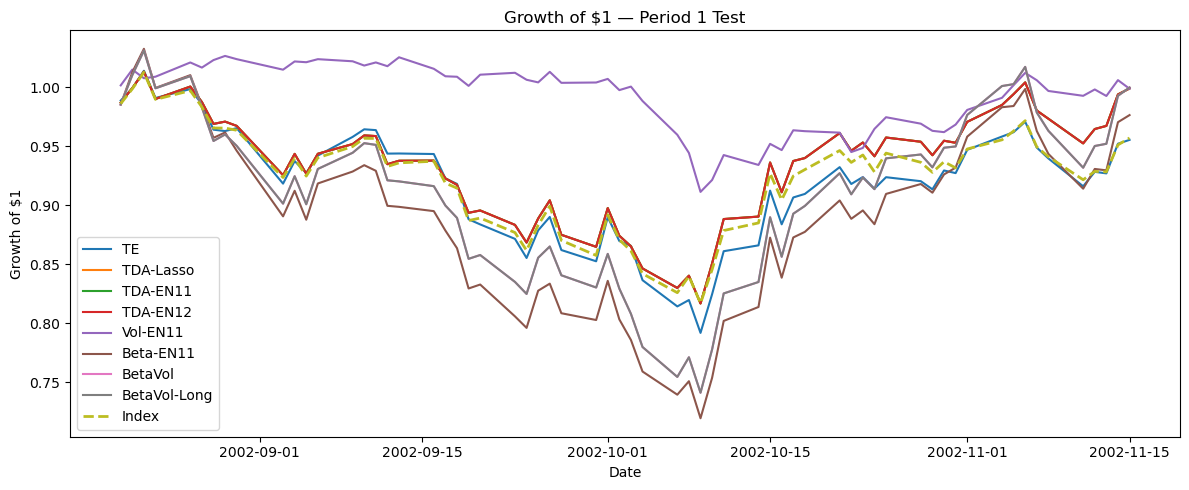

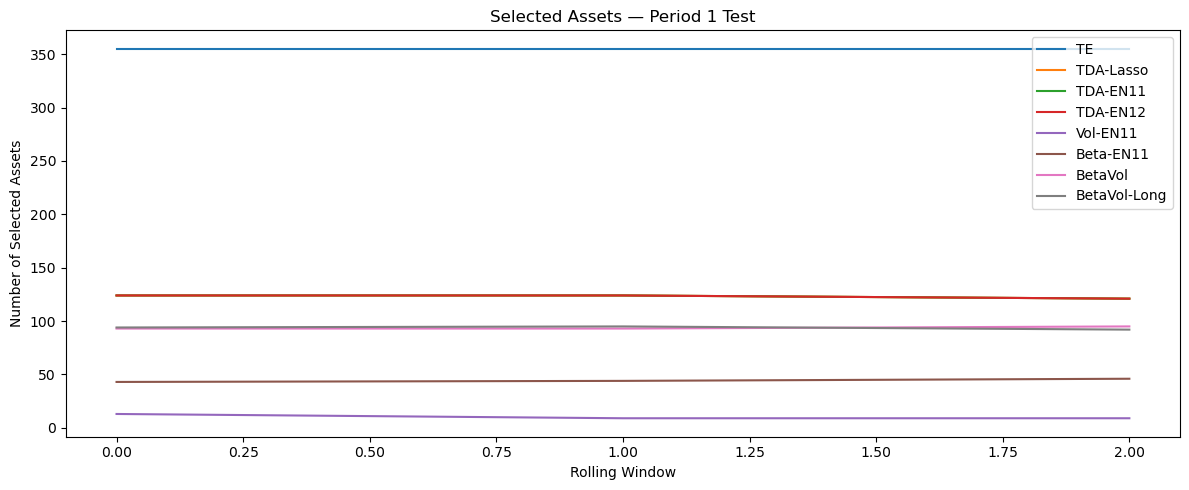

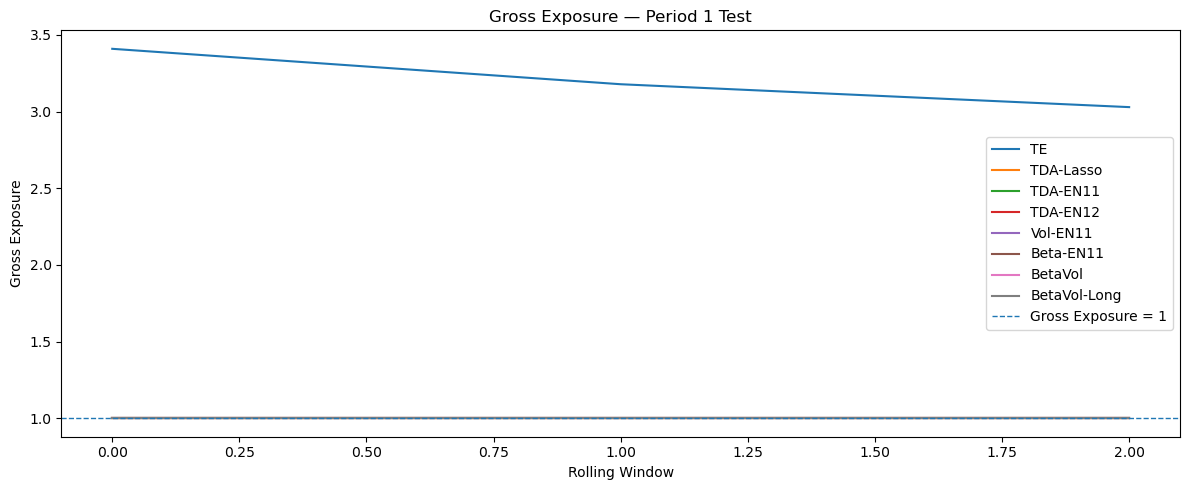

In [51]:
#Test run on 3 windows
outputs_p1_test = run_all_models_for_period(
    windows_p1,
    period_name="Period 1 Test",
    tda_resolution=100,
    num_landscapes=1,
    eps=1e-6,
    var_alpha=0.05,
    max_windows=3
)

table_p1_test = build_table(outputs_p1_test, var_alpha=0.05)
display(table_p1_test)

plot_growth_of_1(outputs_p1_test, "Growth of $1 — Period 1 Test")
plot_selected_assets(outputs_p1_test, "Selected Assets — Period 1 Test")
plot_gross_exposure(outputs_p1_test, "Gross Exposure — Period 1 Test")

### FULL RUN

In [52]:
outputs_p1 = run_all_models_for_period(
    windows_p1,
    period_name="Period 1",
    tda_resolution=100,
    num_landscapes=1,
    eps=1e-6,
    var_alpha=0.05,
    max_windows=None)

outputs_p2 = run_all_models_for_period(
    windows_p2,
    period_name="Period 2",
    tda_resolution=100,
    num_landscapes=1,
    eps=1e-6,
    var_alpha=0.05,
    max_windows=None)


Running TE — Period 1

Window 1/193 | Model: TE | Train: 2000-08-14 to 2002-08-19 | OOS: 2002-08-20 to 2002-09-18
Alpha mean: 0.00000000
Beta mean:  0.00000000
Selected assets: 355
Gross exposure: 3.4099
Solver: CLARABEL

Window 2/193 | Model: TE | Train: 2000-09-13 to 2002-09-18 | OOS: 2002-09-19 to 2002-10-17
Alpha mean: 0.00000000
Beta mean:  0.00000000
Selected assets: 355
Gross exposure: 3.1788
Solver: CLARABEL

Window 3/193 | Model: TE | Train: 2000-10-12 to 2002-10-17 | OOS: 2002-10-18 to 2002-11-15
Alpha mean: 0.00000000
Beta mean:  0.00000000
Selected assets: 355
Gross exposure: 3.0295
Solver: CLARABEL

Window 4/193 | Model: TE | Train: 2000-11-10 to 2002-11-15 | OOS: 2002-11-18 to 2002-12-17
Alpha mean: 0.00000000
Beta mean:  0.00000000
Selected assets: 355
Gross exposure: 2.7597
Solver: CLARABEL

Window 5/193 | Model: TE | Train: 2000-12-12 to 2002-12-17 | OOS: 2002-12-18 to 2003-01-17
Alpha mean: 0.00000000
Beta mean:  0.00000000
Selected assets: 355
Gross exposure: 2.6421

Computing TDA norms: 100%|███████████████████████████████████████████████████████████| 355/355 [00:15<00:00, 23.57it/s]


Alpha mean: 0.01219852
Beta mean:  0.00067602
Selected assets: 124
Gross exposure: 1.0000
Solver: CLARABEL

Window 2/193 | Model: TDA-Lasso | Train: 2000-09-13 to 2002-09-18 | OOS: 2002-09-19 to 2002-10-17


Computing TDA norms: 100%|███████████████████████████████████████████████████████████| 355/355 [00:16<00:00, 21.64it/s]


Alpha mean: 0.01242254
Beta mean:  0.00068603
Selected assets: 124
Gross exposure: 1.0000
Solver: CLARABEL

Window 3/193 | Model: TDA-Lasso | Train: 2000-10-12 to 2002-10-17 | OOS: 2002-10-18 to 2002-11-15


...

Alpha mean: 0.00859617
Beta mean:  0.00056436
Selected assets: 108
Gross exposure: 1.0000
Solver: CLARABEL

Window 37/38 | Model: TDA-EN12 | Train: 2021-01-05 to 2023-01-04 | OOS: 2023-01-05 to 2023-02-03


Computing TDA norms: 100%|███████████████████████████████████████████████████████████| 477/477 [00:19<00:00, 24.58it/s]


Alpha mean: 0.00869184
Beta mean:  0.00056708
Selected assets: 131
Gross exposure: 1.0000
Solver: CLARABEL

Window 38/38 | Model: TDA-EN12 | Train: 2021-02-04 to 2023-02-03 | OOS: 2023-02-06 to 2023-03-07


Computing TDA norms: 100%|███████████████████████████████████████████████████████████| 477/477 [00:19<00:00, 24.48it/s]


Alpha mean: 0.00862861
Beta mean:  0.00056429
Selected assets: 124
Gross exposure: 1.0000
Solver: CLARABEL

Running Vol-EN11 — Period 2

Window 1/38 | Model: Vol-EN11 | eps=1e-06 | Train: 2018-01-03 to 2020-01-03 | OOS: 2020-01-06 to 2020-02-04
Mean CAPM beta: 0.9361
Mean raw sigma: 0.016708
Mean economic alpha: 1.0000
Mean economic b: 1.0000
Selected assets: 36
Gross exposure: 1.0000
Solver: CLARABEL

Window 2/38 | Model: Vol-EN11 | eps=1e-06 | Train: 2018-02-02 to 2020-02-04 | OOS: 2020-02-05 to 2020-03-05
Mean CAPM beta: 0.9376
Mean raw sigma: 0.016717
Mean economic alpha: 1.0000
Mean economic b: 1.0000
Selected assets: 36
Gross exposure: 1.0000
Solver: CLARABEL

Window 3/38 | Model: Vol-EN11 | eps=1e-06 | Train: 2018-03-06 to 2020-03-05 | OOS: 2020-03-06 to 2020-04-03
Mean CAPM beta: 0.9390
Mean raw sigma: 0.017132
Mean economic alpha: 1.0000
Mean economic b: 1.0000
Selected assets: 40
Gross exposure: 1.0000
Solver: CLARABEL

Window 4/38 | Model: Vol-EN11 | eps=1e-06 | Train: 2018-

### RESULT TABLES

In [54]:
table_p1 = build_table(outputs_p1, var_alpha=0.05)
table_p2 = build_table(outputs_p2, var_alpha=0.05)
print("\n=== Period 1 Results ===")
display(table_p1)

print("\n=== Period 2 Results ===")
display(table_p2)


=== Period 1 Results ===


,TError,Correlation,Ann.Return,Volatility,MaxDD,DownsideDev,VaR,CVaR,SHR,IR,TR,# Assets,Gross Exposure,Max Gross Exposure,VaR Failures,VaR Failure Rate,Kupiec LR,Kupiec p-value
Model,,,,,,,,,,,,,,,,,,
TE,0.001678,0.990470,0.122036,0.190308,-0.518142,0.001053,0.016864,0.028679,0.641256,1.328632,0.839791,355.000000,1.958898,3.409907,207,0.051073,0.097631,7.546918e-01
TDA-Lasso,0.001627,0.990237,0.126537,0.183480,-0.521554,0.000991,0.016650,0.027583,0.689648,1.547456,0.395900,117.699482,1.000000,1.000000,211,0.052060,0.357545,5.498731e-01
TDA-EN11,0.001626,0.990241,0.126535,0.183480,-0.521544,0.000991,0.016650,0.027583,0.689641,1.547657,0.395762,117.725389,1.000000,1.000000,211,0.052060,0.357545,5.498731e-01
TDA-EN12,0.001627,0.990237,0.126537,0.183480,-0.521554,0.000991,0.016650,0.027583,0.689648,1.547457,0.395899,117.699482,1.000000,1.000000,211,0.052060,0.357545,5.498731e-01
Vol-EN11,0.007474,0.772021,0.137302,0.123399,-0.299109,0.005146,0.010982,0.017616,1.112665,0.426070,0.190349,18.191710,1.000000,1.000000,274,0.067604,23.933384,9.972732e-07
Beta-EN11,0.010861,0.922685,0.191472,0.326994,-0.647774,0.007373,0.031197,0.048358,0.585553,0.607703,0.208271,33.994819,1.000000,1.000000,180,0.044412,2.764519,9.637564e-02
BetaVol,0.008579,0.946875,0.186003,0.296954,-0.623272,0.005720,0.027882,0.044375,0.626369,0.729372,0.144907,74.222798,1.000000,1.000000,184,0.045398,1.861779,1.724197e-01
BetaVol-Long,0.008579,0.946875,0.186003,0.296954,-0.623271,0.005720,0.027882,0.044375,0.626370,0.729375,0.144908,74.398964,1.000000,1.000000,184,0.045398,1.861779,1.724197e-01



=== Period 2 Results ===


,TError,Correlation,Ann.Return,Volatility,MaxDD,DownsideDev,VaR,CVaR,SHR,IR,TR,# Assets,Gross Exposure,Max Gross Exposure,VaR Failures,VaR Failure Rate,Kupiec LR,Kupiec p-value
Model,,,,,,,,,,,,,,,,,,
TE,0.003606,0.975518,0.103410,0.260077,-0.361383,0.002487,0.022835,0.039050,0.397612,0.102957,5.265359,477.000000,5.767097,8.402534,52,0.065163,3.540372,0.059892
TDA-Lasso,0.002019,0.991917,0.135600,0.251964,-0.353294,0.001334,0.022999,0.038670,0.538170,1.191067,0.394761,127.078947,0.999999,1.000000,48,0.060150,1.630025,0.201700
TDA-EN11,0.002019,0.991917,0.135597,0.251965,-0.353310,0.001334,0.023000,0.038670,0.538158,1.191006,0.394607,127.131579,0.999999,1.000000,48,0.060150,1.630025,0.201700
TDA-EN12,0.002019,0.991917,0.135600,0.251964,-0.353294,0.001334,0.022999,0.038670,0.538170,1.191067,0.394761,127.052632,0.999999,1.000000,48,0.060150,1.630025,0.201700
Vol-EN11,0.008967,0.823876,0.038379,0.216935,-0.383302,0.006420,0.016097,0.033865,0.176914,-0.415289,0.206529,21.894737,1.000000,1.000000,48,0.060150,1.630025,0.201700
Beta-EN11,0.013042,0.913422,0.323293,0.408621,-0.434419,0.008342,0.037309,0.057913,0.791181,1.092438,0.216767,43.789474,1.000000,1.000000,46,0.057644,0.937602,0.332895
BetaVol,0.010426,0.933884,0.283281,0.372776,-0.393007,0.006602,0.034049,0.052779,0.759923,1.124527,0.159135,91.973684,1.000000,1.000000,46,0.057644,0.937602,0.332895
BetaVol-Long,0.010426,0.933884,0.283281,0.372776,-0.393007,0.006601,0.034048,0.052779,0.759924,1.124529,0.159135,92.105263,1.000000,1.000000,46,0.057644,0.937602,0.332895


#### PENALTY COMPARISON

,Pearson Corr,Spearman Corr,N pooled window-asset obs
Comparison,,,
TDA alpha H0 vs Economic inverse-beta alpha,-0.162177,-0.535917,68515
TDA beta H1 vs Economic volatility b,0.587414,0.573882,68515


,Pearson: TDA alpha vs Econ alpha,Spearman: TDA alpha vs Econ alpha,Pearson: TDA beta vs Econ b,Spearman: TDA beta vs Econ b
count,193.000000,193.000000,193.000000,193.000000
mean,-0.432232,-0.613456,0.682774,0.684220
std,0.134387,0.085645,0.052724,0.075918
min,-0.648069,-0.765029,0.446265,0.482223
25%,-0.568689,-0.682874,0.656541,0.632140
50%,-0.411681,-0.615279,0.698376,0.693461
75%,-0.372141,-0.544333,0.719261,0.739981
max,0.010205,-0.401559,0.763095,0.814272


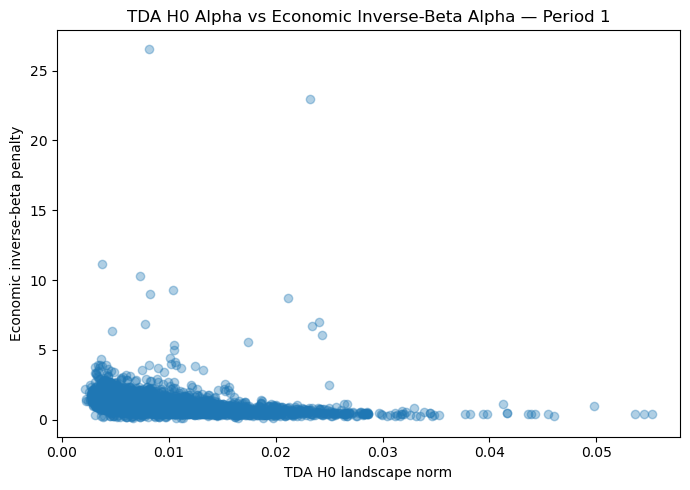

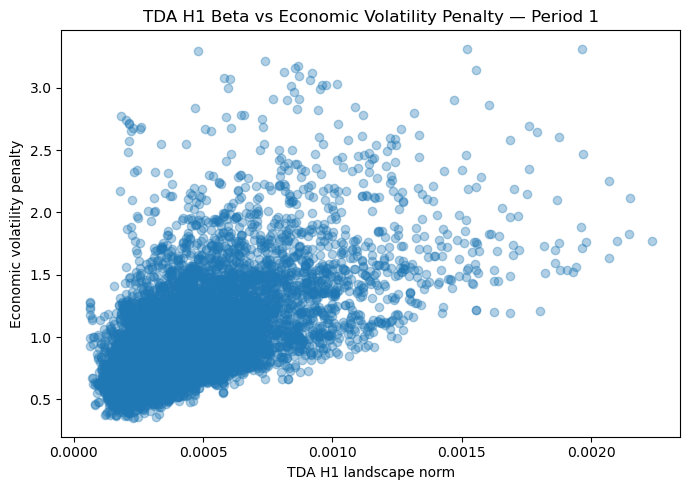

,Pearson Corr,Spearman Corr,N pooled window-asset obs
Comparison,,,
TDA alpha H0 vs Economic inverse-beta alpha,-0.266915,-0.459126,18126
TDA beta H1 vs Economic volatility b,0.584570,0.533325,18126


,Pearson: TDA alpha vs Econ alpha,Spearman: TDA alpha vs Econ alpha,Pearson: TDA beta vs Econ b,Spearman: TDA beta vs Econ b
count,38.000000,38.000000,38.000000,38.000000
mean,-0.299453,-0.507887,0.638509,0.623302
std,0.086700,0.118693,0.089575,0.080699
min,-0.458138,-0.675322,0.396913,0.372387
25%,-0.337478,-0.609830,0.594075,0.588931
50%,-0.299926,-0.480098,0.635814,0.618817
75%,-0.254824,-0.452259,0.701618,0.674201
max,-0.083333,-0.173147,0.772476,0.734500


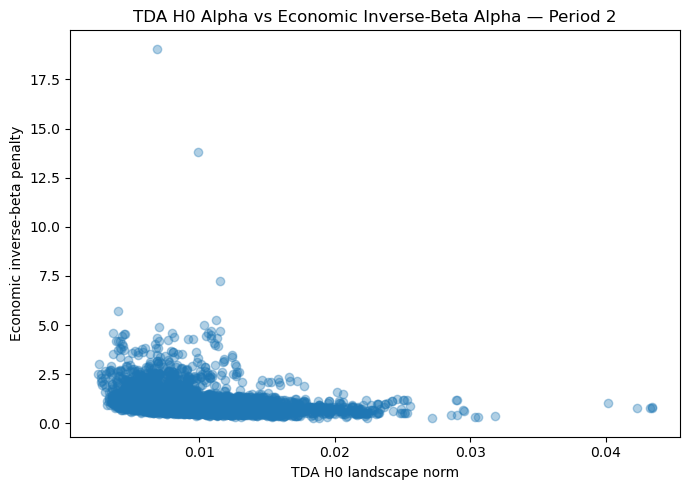

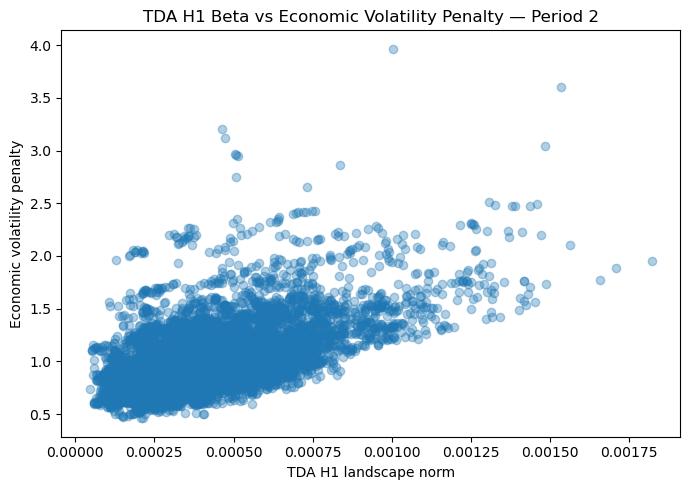

In [56]:
#PERIOD 1
penalty_corr_p1 = penalty_correlation_table(
    tda_alpha_df=outputs_p1["TDA-EN12"]["alpha_tda"],
    tda_beta_df=outputs_p1["TDA-EN12"]["beta_tda"],
    econ_alpha_df=outputs_p1["BetaVol"]["alpha_beta"],
    econ_b_df=outputs_p1["BetaVol"]["b_vol"])
display(penalty_corr_p1)

penalty_corr_by_window_p1 = penalty_correlation_by_window(
    tda_alpha_df=outputs_p1["TDA-EN12"]["alpha_tda"],
    tda_beta_df=outputs_p1["TDA-EN12"]["beta_tda"],
    econ_alpha_df=outputs_p1["BetaVol"]["alpha_beta"],
    econ_b_df=outputs_p1["BetaVol"]["b_vol"])

display(penalty_corr_by_window_p1.describe())

plot_penalty_scatter_all_windows(
    tda_alpha_df=outputs_p1["TDA-EN12"]["alpha_tda"],
    tda_beta_df=outputs_p1["TDA-EN12"]["beta_tda"],
    econ_alpha_df=outputs_p1["BetaVol"]["alpha_beta"],
    econ_b_df=outputs_p1["BetaVol"]["b_vol"],
    sample_size=10000,
    title_suffix="— Period 1")


#PERIOD 2
penalty_corr_p2 = penalty_correlation_table(
    tda_alpha_df=outputs_p2["TDA-EN12"]["alpha_tda"],
    tda_beta_df=outputs_p2["TDA-EN12"]["beta_tda"],
    econ_alpha_df=outputs_p2["BetaVol"]["alpha_beta"],
    econ_b_df=outputs_p2["BetaVol"]["b_vol"])

display(penalty_corr_p2)

penalty_corr_by_window_p2 = penalty_correlation_by_window(
    tda_alpha_df=outputs_p2["TDA-EN12"]["alpha_tda"],
    tda_beta_df=outputs_p2["TDA-EN12"]["beta_tda"],
    econ_alpha_df=outputs_p2["BetaVol"]["alpha_beta"],
    econ_b_df=outputs_p2["BetaVol"]["b_vol"])

display(penalty_corr_by_window_p2.describe())

plot_penalty_scatter_all_windows(
    tda_alpha_df=outputs_p2["TDA-EN12"]["alpha_tda"],
    tda_beta_df=outputs_p2["TDA-EN12"]["beta_tda"],
    econ_alpha_df=outputs_p2["BetaVol"]["alpha_beta"],
    econ_b_df=outputs_p2["BetaVol"]["b_vol"],
    sample_size=10000,
    title_suffix="— Period 2")

### EPSILON SENSITIVITY CHECK

In [58]:
eps_grid = [1e-8, 1e-6, 1e-4, 1e-2]

eps_sens_p1, eps_outputs_p1 = run_epsilon_sensitivity(
    windows_p1,
    eps_grid=eps_grid,
    model="BetaVol",
    annualise_vol=False,
    normalize=True,
    var_alpha=0.05,
    max_windows=None)

print("\n=== Epsilon Sensitivity: Period 1 ===")
display(eps_sens_p1)

eps_sens_p2, eps_outputs_p2 = run_epsilon_sensitivity(
    windows_p2,
    eps_grid=eps_grid,
    model="BetaVol",
    annualise_vol=False,
    normalize=True,
    var_alpha=0.05,
    max_windows=None)

print("\n=== Epsilon Sensitivity: Period 2 ===")
display(eps_sens_p2)


Epsilon sensitivity: model=BetaVol, eps=1e-08

Window 1/193 | Model: BetaVol | eps=1e-08 | Train: 2000-08-14 to 2002-08-19 | OOS: 2002-08-20 to 2002-09-18
Mean CAPM beta: 0.8608
Mean raw sigma: 0.029344
Mean economic alpha: 1.0000
Mean economic b: 1.0000
Selected assets: 93
Gross exposure: 1.0000
Solver: CLARABEL

Window 2/193 | Model: BetaVol | eps=1e-08 | Train: 2000-09-13 to 2002-09-18 | OOS: 2002-09-19 to 2002-10-17
Mean CAPM beta: 0.8664
Mean raw sigma: 0.029366
Mean economic alpha: 1.0000
Mean economic b: 1.0000
Selected assets: 93
Gross exposure: 1.0000
Solver: CLARABEL

Window 3/193 | Model: BetaVol | eps=1e-08 | Train: 2000-10-12 to 2002-10-17 | OOS: 2002-10-18 to 2002-11-15
Mean CAPM beta: 0.8746
Mean raw sigma: 0.029748
Mean economic alpha: 1.0000
Mean economic b: 1.0000
Selected assets: 95
Gross exposure: 1.0000
Solver: CLARABEL

Window 4/193 | Model: BetaVol | eps=1e-08 | Train: 2000-11-10 to 2002-11-15 | OOS: 2002-11-18 to 2002-12-17
Mean CAPM beta: 0.8837
Mean raw sigma

TError  Correlation  Ann.Return  Volatility     MaxDD  \
Model   eps                                                                     
BetaVol 1.000000e-08  0.008579     0.946875    0.186003    0.296954 -0.623272   
        1.000000e-06  0.008579     0.946875    0.186003    0.296954 -0.623272   
        1.000000e-04  0.008579     0.946875    0.186004    0.296957 -0.623271   
        1.000000e-02  0.008585     0.946822    0.185933    0.297033 -0.623242   

                           VaR      CVaR       SHR        IR        TR  \
Model   eps                                                              
BetaVol 1.000000e-08  0.027882  0.044375  0.626369  0.729371  0.144911   
        1.000000e-06  0.027882  0.044375  0.626369  0.729372  0.144907   
        1.000000e-04  0.027881  0.044375  0.626369  0.729370  0.144514   
        1.000000e-02  0.027876  0.044376  0.625968  0.728365  0.138805   

                       # Assets  Gross Exposure  VaR Failure Rate  \
Model   eps                                                         
BetaVol 1.000000e-08  74.222798             1.0          0.045398   
        1.000000e-06  74.222798             1.0          0.045398   
        1.000000e-04  74.207254             1.0          0.045398   
        1.000000e-02  73.994819             1.0          0.045398   

                      Kupiec p-value  
Model   eps                           
BetaVol 1.000000e-08         0.17242  
        1.000000e-06         0.17242  
        1.000000e-04         0.17242  
        1.000000e-02         0.17242


Epsilon sensitivity: model=BetaVol, eps=1e-08

Window 1/38 | Model: BetaVol | eps=1e-08 | Train: 2018-01-03 to 2020-01-03 | OOS: 2020-01-06 to 2020-02-04
Mean CAPM beta: 0.9361
Mean raw sigma: 0.016708
Mean economic alpha: 1.0000
Mean economic b: 1.0000
Selected assets: 82
Gross exposure: 1.0000
Solver: CLARABEL

Window 2/38 | Model: BetaVol | eps=1e-08 | Train: 2018-02-02 to 2020-02-04 | OOS: 2020-02-05 to 2020-03-05
Mean CAPM beta: 0.9376
Mean raw sigma: 0.016717
Mean economic alpha: 1.0000
Mean economic b: 1.0000
Selected assets: 87
Gross exposure: 1.0000
Solver: CLARABEL

Window 3/38 | Model: BetaVol | eps=1e-08 | Train: 2018-03-06 to 2020-03-05 | OOS: 2020-03-06 to 2020-04-03
Mean CAPM beta: 0.9390
Mean raw sigma: 0.017132
Mean economic alpha: 1.0000
Mean economic b: 1.0000
Selected assets: 77
Gross exposure: 1.0000
Solver: CLARABEL

Window 4/38 | Model: BetaVol | eps=1e-08 | Train: 2018-04-05 to 2020-04-03 | OOS: 2020-04-06 to 2020-05-05
Mean CAPM beta: 1.0169
Mean raw sigma: 0.

TError  Correlation  Ann.Return  Volatility     MaxDD  \
Model   eps                                                                     
BetaVol 1.000000e-08  0.010426     0.933884    0.283281    0.372776 -0.393007   
        1.000000e-06  0.010426     0.933884    0.283281    0.372776 -0.393007   
        1.000000e-04  0.010426     0.933884    0.283278    0.372776 -0.393009   
        1.000000e-02  0.010429     0.933894    0.283005    0.372847 -0.393200   

                           VaR      CVaR       SHR        IR        TR  \
Model   eps                                                              
BetaVol 1.000000e-08  0.034049  0.052779  0.759923  1.124527  0.159135   
        1.000000e-06  0.034049  0.052779  0.759923  1.124527  0.159135   
        1.000000e-04  0.034049  0.052779  0.759913  1.124504  0.159136   
        1.000000e-02  0.034032  0.052800  0.759037  1.122486  0.159187   

                       # Assets  Gross Exposure  VaR Failure Rate  \
Model   eps                                                         
BetaVol 1.000000e-08  91.973684             1.0          0.057644   
        1.000000e-06  91.973684             1.0          0.057644   
        1.000000e-04  91.973684             1.0          0.057644   
        1.000000e-02  92.026316             1.0          0.057644   

                      Kupiec p-value  
Model   eps                           
BetaVol 1.000000e-08        0.332895  
        1.000000e-06        0.332895  
        1.000000e-04        0.332895  
        1.000000e-02        0.332895

### FINAL PLOTS

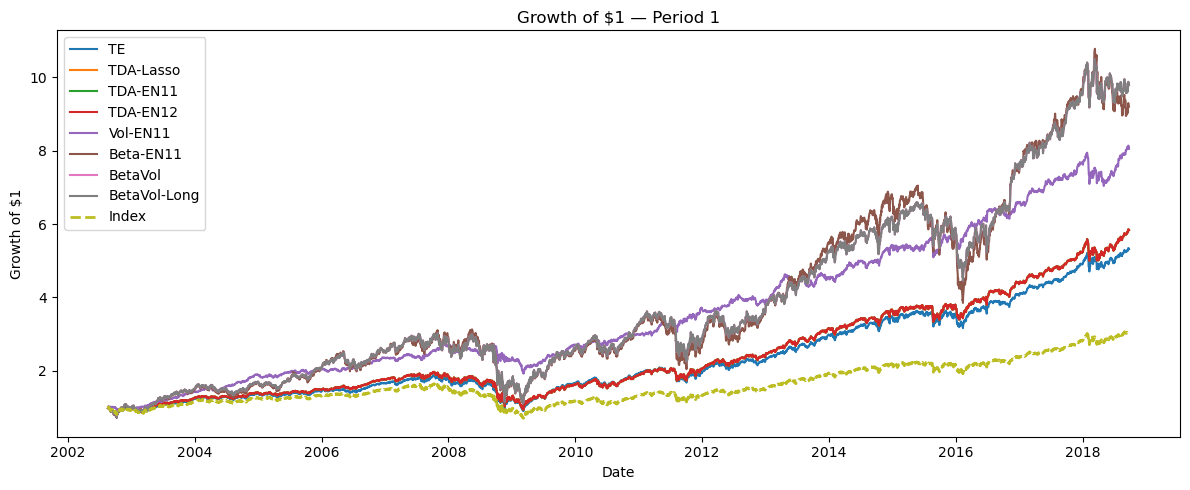

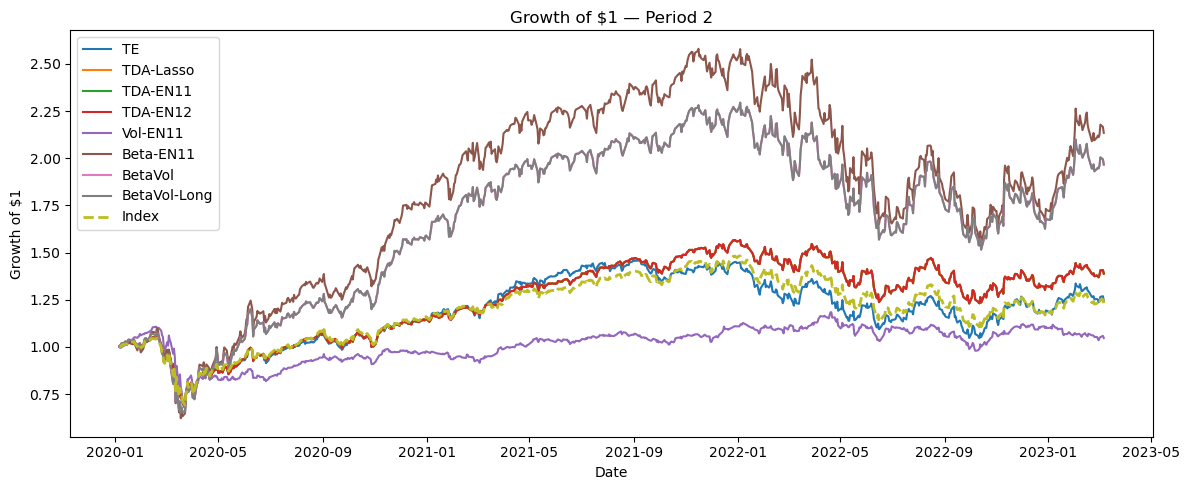

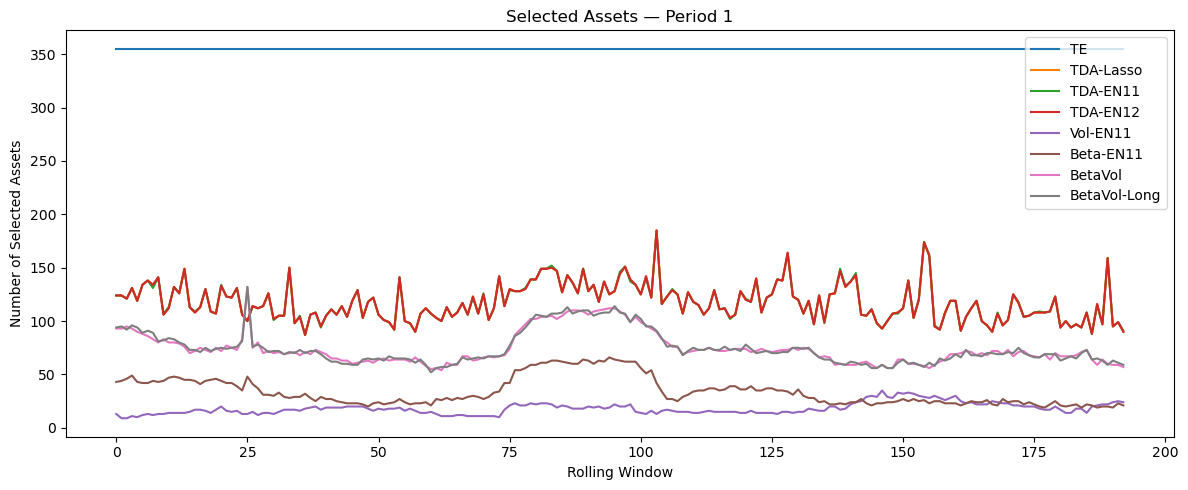

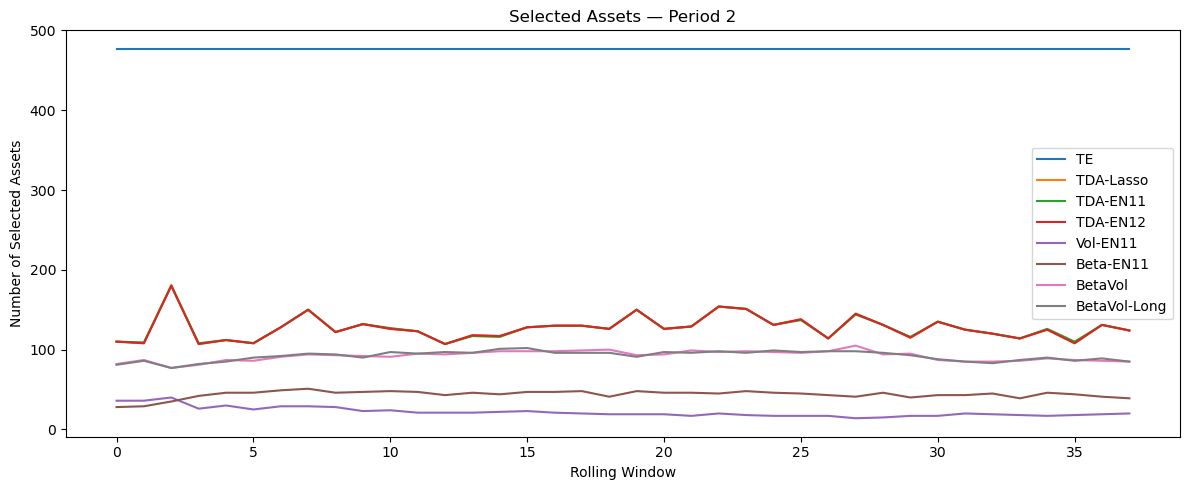

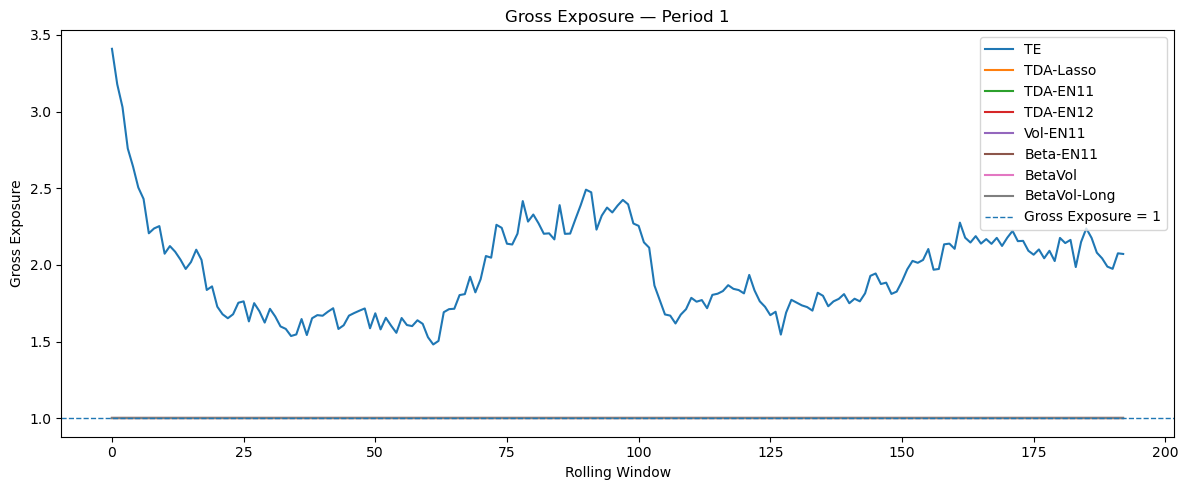

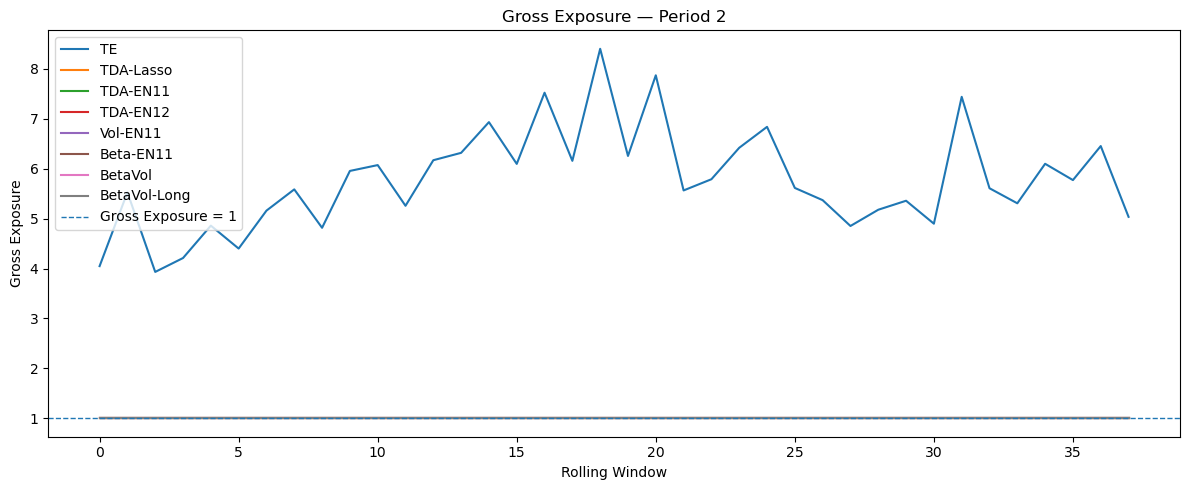

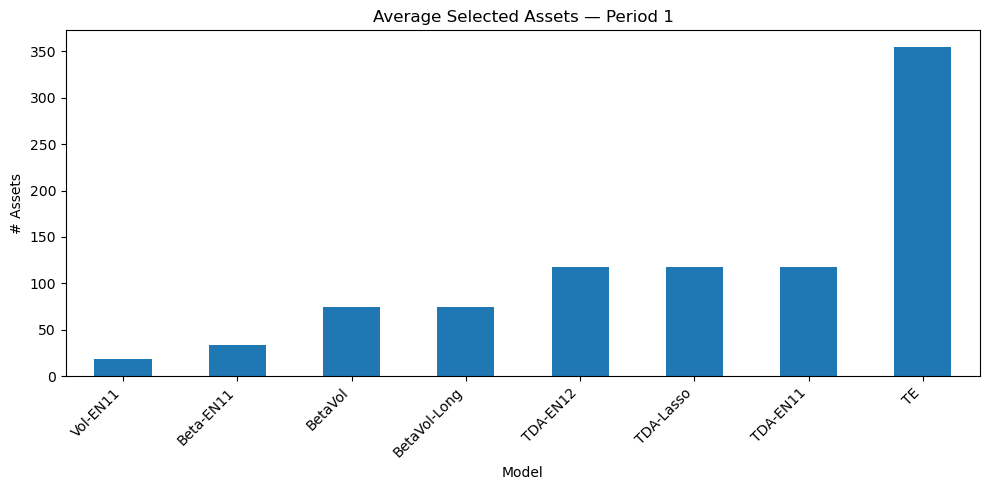

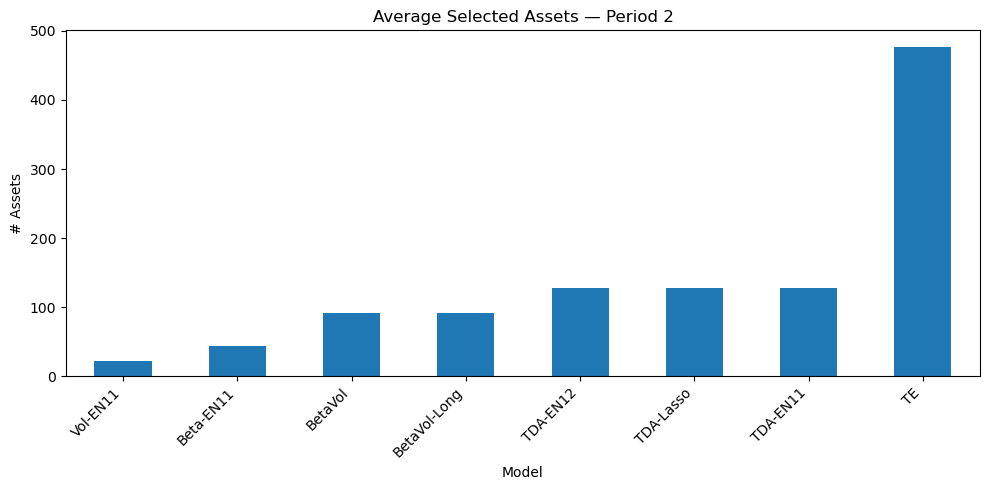

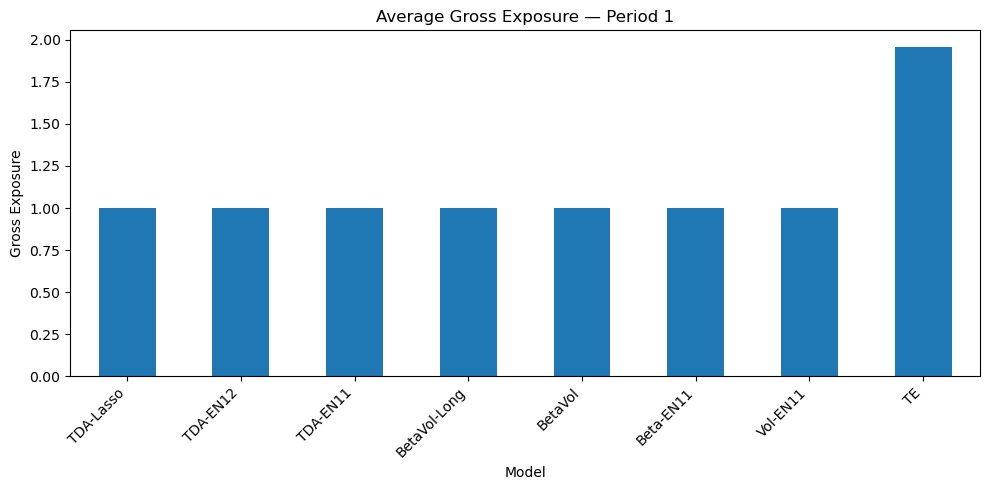

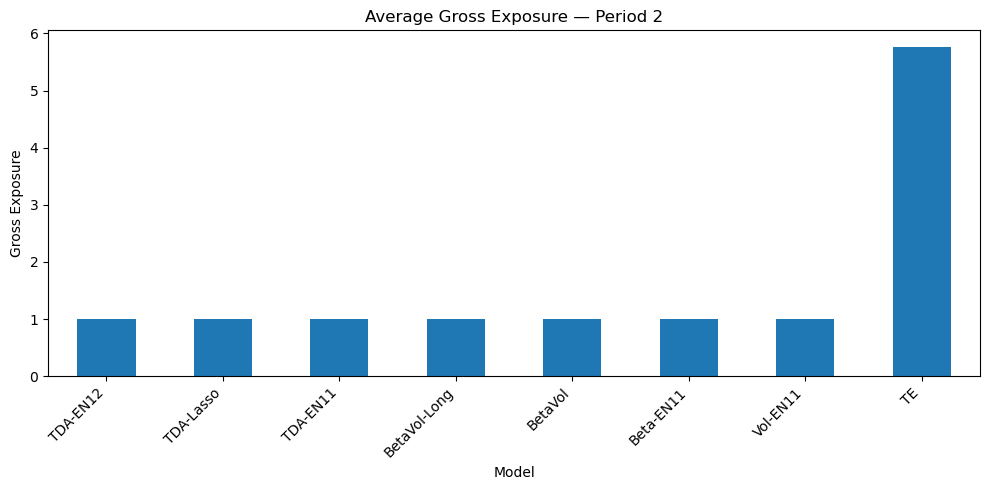

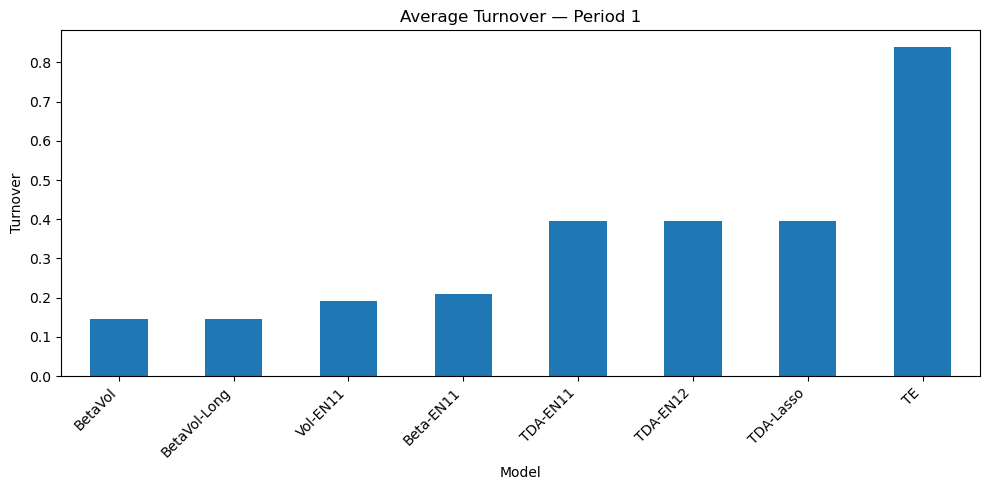

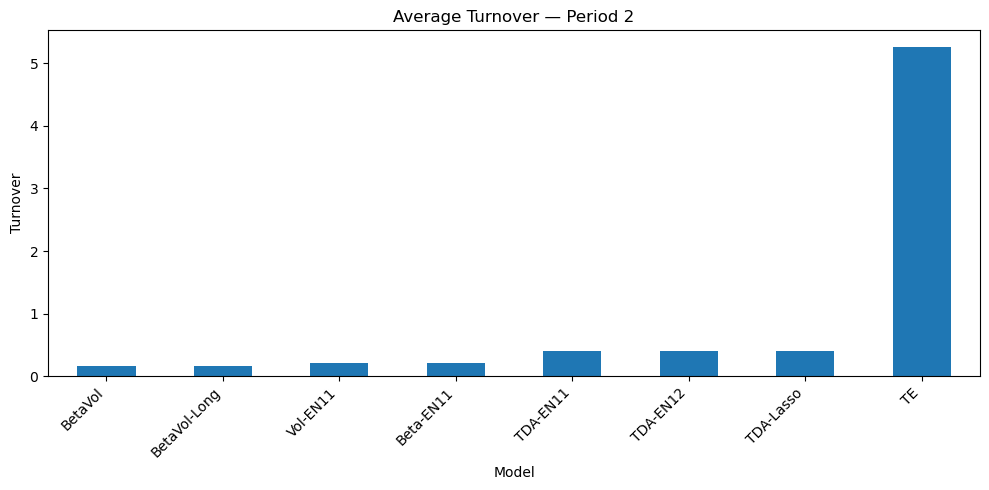

In [59]:
plot_growth_of_1(outputs_p1, "Growth of $1 — Period 1")
plot_growth_of_1(outputs_p2, "Growth of $1 — Period 2")

plot_selected_assets(outputs_p1, "Selected Assets — Period 1")
plot_selected_assets(outputs_p2, "Selected Assets — Period 2")

plot_gross_exposure(outputs_p1, "Gross Exposure — Period 1")
plot_gross_exposure(outputs_p2, "Gross Exposure — Period 2")

plot_average_bars(outputs_p1, variable="# Assets", title="Average Selected Assets — Period 1")
plot_average_bars(outputs_p2, variable="# Assets", title="Average Selected Assets — Period 2")

plot_average_bars(outputs_p1, variable="Gross Exposure", title="Average Gross Exposure — Period 1")
plot_average_bars(outputs_p2, variable="Gross Exposure", title="Average Gross Exposure — Period 2")

plot_average_bars(outputs_p1, variable="Turnover", title="Average Turnover — Period 1")
plot_average_bars(outputs_p2, variable="Turnover", title="Average Turnover — Period 2")

### SAVE TABLES

In [60]:
import os
save_outputs = True
save_path = r"C:\Users\chira\OneDrive\Desktop"

if save_outputs:
    table_p1.to_excel(os.path.join(save_path, "table_period1_full_results.xlsx"))
    table_p2.to_excel(os.path.join(save_path, "table_period2_full_results.xlsx"))

    penalty_corr_p1.to_excel(os.path.join(save_path, "penalty_correlation_period1.xlsx"))
    penalty_corr_p2.to_excel(os.path.join(save_path, "penalty_correlation_period2.xlsx"))

    penalty_corr_by_window_p1.to_excel(os.path.join(save_path, "penalty_correlation_by_window_period1.xlsx"))
    penalty_corr_by_window_p2.to_excel(os.path.join(save_path, "penalty_correlation_by_window_period2.xlsx"))

    eps_sens_p1.to_excel(os.path.join(save_path, "epsilon_sensitivity_period1.xlsx"))
    eps_sens_p2.to_excel(os.path.join(save_path, "epsilon_sensitivity_period2.xlsx"))

    print(f"Saved result tables successfully to: {save_path}")

Saved result tables successfully to: C:\Users\chira\OneDrive\Desktop
